<a href="https://colab.research.google.com/github/SampMark/Deep-Learning/blob/main/Fruit_Classification_Using_Transfer_Learning_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Classificação de frutas usando _Transfer Learning_ (v.1)**

Este notebook de classificação de frutas emprega uma das técnicas mais poderosas em visão computacional: o **Transfer Learning**. Neste notebook, o objetivo é construir um classificador capaz de identificar e diferenciar diversas variedades de frutas a partir de imagens, valendo-se do modelo **VGG16** pré-treinado em ImageNet.

O Transfer Learning reutiliza o conhecimento adquirido em uma tarefa anterior para acelerar o treinamento e aumentar a acurácia em uma nova tarefa. Em vez de treinar uma rede neural do zero — processo que demanda alto custo computacional e grandes volumes de dados — aproveitamos modelos já treinados em bases massivas, como o ImageNet (com milhões de imagens rotuladas), para extrair características visuais genéricas (bordas, texturas, formas etc.).

Ao incorporar essas representações pré-aprendidas, reduzimos significativamente o tempo de treinamento e conseguimos desempenho superior em aplicações específicas, como a classificação automática de frutas, sem abrir mão da robustez e da precisão.


### **Sobre a escolha de um dataset**

A escolha de um dataset de frutas de boa qualidade é crucial. Existem _datasets_ públicos disponíveis, como por exemplo, o "Fruits-360", "Fruits and Vegetables Image Dataset".
Em linhas gerais, o dataset deve conter imagens de diversas frutas, com variações de iluminação, ângulo, maturação e, idealmente, algumas imagens com fundo complexo para simular condições reais. As imagens devem ser organizadas em pastas, onde cada pasta representa uma classe de fruta (ex: "Maca", "Banana", "Laranja").

### **O dataset Fruits-360**

Neste notebook será utilizado o dataset **Fruits-360**, essa base de dados contém imagens de frutas, vegetais, nozes e sementes, nas seguintes versões:

  * **Fruits-360 100x100**: contém 136.793 fotos de 200 frutas, vegetais, nozes e sementes e as imagens estão redimensionadas para $100 \times 100$ pixels.

  * **Fruits-360 original-size**: contém 56.424 fotos de 84 frutas, vegetais, nozes e sementes, as imagens são armazenadas no tamanho original de captura, visando preservar informações como textura da casca e outros artefatos que eram perdidos no redimensionamento, atendendo a pesquisadores cujos algoritmos são mais adequados para outros tamanhos de imagem.

O repositório oficial do dataset está no Kaggle (https://www.kaggle.com/datasets/moltean/fruits), e os metadados, que também estão incluídos no arquivo do dataset, são mantidos com um sistema de versionamento no GitHub (https://github.com/fruits-360).

### **Estrutura do Código**

O notebook tem as seguintes etapas:

1.  **Configurações iniciais:** alocação de GPU NVIDIA A100-SXM4-40GB, instalação de dependências e importação de bibliotecas, definição de caminhos para o conjunto de dados.
2.  **Preparação dos Dados:** Criação de geradores de dados para carregar, aumentar (data augmentation) e pré-processar as imagens de treinamento, validação e teste.
3.  **Construção do Modelo:** Definição da arquitetura do modelo utilizando o VGG16 como base e adicionando camadas personalizadas para a classificação de frutas.
4.  **Compilação do Modelo:** Configuração da função de perda, otimizador e métricas para o treinamento.
5.  **Treinamento Inicial:** Treinamento das camadas personalizadas do modelo, mantendo o VGG16 "congelado".
6.  **Ajuste Fino (Fine-tuning):** "Descongelamento" de algumas camadas superiores do VGG16 e continuação do treinamento com uma taxa de aprendizado menor para especializar o modelo no dataset de frutas.
7.  **Avaliação do Modelo e Visualização do Desempenho:** Verificação do desempenho do modelo no conjunto de teste e plotagem das curvas de acurácia e perda durante o treinamento.
8.  **Teste com Imagens de Amostra:** Realização de predições em imagens de exemplo e visualização dos resultados.

In [1]:
# -*- coding: utf-8 -*-
"""Fruit_Classification_Using_Transfer_Learning_KaggleHub.ipynb

# **Classificação de Frutas Usando Transfer Learning v.1 (com KaggleHub)**
"""
# @title **Etapa 1: Configurações iniciais, carregamento e pré-processamento do dataset Fruits-360**

# Aloque uma GPU
!nvidia-smi

Fri May 16 22:11:57 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   64C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### **Detalhamento do Dataset Fruits-360 (_branch original-size_)**

#### Propriedades do dataset

* **Total de imagens:** 56 424
* **Classes:** 84 (frutas, vegetais, nozes e sementes)
* **Divisão:**

  * *Training:* 28.250 imagens (\~50 %)
  * *Validation:* 14.128 imagens (\~25 %)
  * *Test:* 14.046 imagens (\~25 %)
* **Tamanhos originais:** variados — cada imagem mantém sua resolução capturada originalmente (sem redimensionamento automático) .

**Outros detalhes**:

  * **Mais informações e novos objetos:** há mais informações sobre os objetos e há novos objetos com características distintas, como a presença de doenças e diferentes estágios de crescimento (imaturos ou excessivamente maduros).

  * **Remoção de Fundo:** segundo os autores, o algoritmo para remover o fundo das imagens foi melhorado e houve melhorias na remoção do eixo do motor usado para rotacionar os objetos durante a captura das imagens.

### Estrutura de diretórios e nomeação

```
fruits-360-original-size/
├─ Training/
│   ├─ Apple Golden 1/
│   │   ├─ r0_1.jpg
│   │   ├─ r1_2.jpg
│   │   └─ …
│   ├─ Banana Lady Finger/
│   └─ …
├─ Validation/
│   └─ … (mesma estrutura de classes)
└─ Test/
    └─ … (mesma estrutura de classes)
```

* Cada subpasta corresponde a uma classe (por exemplo, `Apple Golden 1` e `Banana Lady Finger`).
* Arquivos seguem o padrão `rX_Y.jpg`, em que `rX` indica a rotação aplicada e `Y` é o índice da imagem .

### Referências alternativas de download

* **Kaggle:** [https://www.kaggle.com/moltean/fruits](https://www.kaggle.com/moltean/fruits)
* **GitHub oficial:** [https://github.com/fruits-360](https://github.com/fruits-360) .


É pssível integrar o *fruits-360-original-size* de modo eficiente a qualquer _workflow_ de treinamento de CNN, otimizando-se desde o pré-processamento até a fase de fine-tuning.


In [2]:
# Instalar dependências, incluindo kagglehub
!pip install tensorflow scikit-learn scipy kagglehub

In [3]:
# Importar bibliotecas necessárias
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.mixed_precision import set_global_policy
from collections import Counter
import kagglehub # Importar kagglehub
# Para caso o download do kagglehub seja um ZIP ou para inspecionar a estrutura do dataset se necessário
import zipfile

In [4]:
# @title Etapa 1. Carregamento do Fruits-360 e pré-processamento em Keras

print("Iniciando o download do dataset Fruits-360 via KaggleHub...")
# Fazer o download do dataset "moltean/fruits"
try:
    # O kagglehub baixa para um local padrão. A função retorna o caminho para este local.
    downloaded_path = kagglehub.dataset_download("moltean/fruits")
    print(f"Dataset baixado com sucesso. Caminho base do download: {downloaded_path}")

    # Como a estrutura do dataset baixado pode variar.
    # Precisamos encontrar a pasta que contém os subdiretórios 'Training', 'Validation', 'Test'.
    dataset_root_path = None
    print("\nProcurando pela pasta raiz do dataset ('Training', 'Validation', 'Test' folders) dentro do caminho baixado...")

    # Percorre o caminho baixado e suas subpastas para encontrar a estrutura correta
    for root, dirs, files in os.walk(downloaded_path):
        # Verifica se os diretórios Training, Validation e Test estão presentes na pasta atual
        if 'Training' in dirs and 'Validation' in dirs and 'Test' in dirs:
            dataset_root_path = root # Esta é a pasta raiz do dataset que queremos usar
            print(f"Pasta raiz do dataset encontrada em: {dataset_root_path}")
            break # Encontramos a pasta, podemos parar a busca

    if dataset_root_path is None:
        # Se após a busca não encontramos a pasta raiz esperada
        print(f"Conteúdo do caminho baixado ({downloaded_path}) para ajudar na depuração:")
        # Listar apenas os primeiros níveis para não ser muito verboso
        for root, dirs, files in os.walk(downloaded_path):
            level = root.replace(downloaded_path, '').count(os.sep)
            if level < 3: # Listar até 2 níveis de profundidade
                print(f"{'  ' * level} Pasta: {os.path.basename(root) if root != downloaded_path else downloaded_path}")
                if dirs:
                     print(f"{'  ' * (level + 1)} Subpastas: {dirs}")
                if files and level == 0: # Mostrar arquivos na raiz
                     print(f"{'  ' * (level + 1)} Arquivos: {files}")
            if level >= 2: # Limitar profundidade
                 dirs[:] = [] # Don't traverse deeper

        raise FileNotFoundError(f"Não foi possível encontrar a pasta contendo 'Training', 'Validation' e 'Test' dentro de '{downloaded_path}'. Verifique a estrutura do dataset baixado.")

    # Definir caminhos para os diretórios de Treinamento, Validação e Teste
    train_dir = os.path.join(dataset_root_path, 'Training')
    val_dir = os.path.join(dataset_root_path, 'Validation')
    test_dir = os.path.join(dataset_root_path, 'Test')

    print(f"\nCaminho de Treinamento definido para: {train_dir}")
    print(f"Caminho de Validação definido para: {val_dir}")
    print(f"Caminho de Teste definido para: {test_dir}")

    # Verificar se os caminhos de fato existem (redundante, mas seguro)
    if not os.path.exists(train_dir):
        raise FileNotFoundError(f"Diretório de treinamento não encontrado: {train_dir}.")
    if not os.path.exists(val_dir):
        raise FileNotFoundError(f"Diretório de validação não encontrado: {val_dir}.")
    if not os.path.exists(test_dir):
        raise FileNotFoundError(f"Diretório de teste não encontrado: {test_dir}.")

except Exception as e:
    print(f"Ocorreu um erro durante o download ou configuração dos caminhos: {e}")
    print("Verifique sua conexão com a internet, as credenciais do Kaggle e a estrutura esperada do dataset.")
    # Parar a execução se o dataset não puder ser carregado
    raise

Iniciando o download do dataset Fruits-360 via KaggleHub...
Dataset baixado com sucesso. Caminho base do download: /kaggle/input/fruits

Procurando pela pasta raiz do dataset ('Training', 'Validation', 'Test' folders) dentro do caminho baixado...
Pasta raiz do dataset encontrada em: /kaggle/input/fruits/fruits-360_original-size/fruits-360-original-size

Caminho de Treinamento definido para: /kaggle/input/fruits/fruits-360_original-size/fruits-360-original-size/Training
Caminho de Validação definido para: /kaggle/input/fruits/fruits-360_original-size/fruits-360-original-size/Validation
Caminho de Teste definido para: /kaggle/input/fruits/fruits-360_original-size/fruits-360-original-size/Test


In [5]:
# @title **Etapa 2: Configurar geradores de dados para treinamento, validação e teste com aumento de dados**

# Parâmetros para os geradores
# Ajustar IMG_SIZE e BATCH_SIZE conforme a informação que você forneceu (224,224 e 32)
# Para usar as configurações otimizadas para VGG16, isto exigirá ajustar
# o input_shape do base_model na Etapa 3.

TARGET_IMG_SIZE = (64, 64)
BATCH_SIZE_SCRIPT = 16

# Geradores de dados de imagem
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,         # Re-escala os valores dos pixels de [0, 255] para [0, 1]
    rotation_range=20,         # Faixa de rotação aleatória (graus)
    width_shift_range=0.1,     # Faixa de translação horizontal aleatória (fração da largura total)
    height_shift_range=0.2,    # Faixa de translação vertical aleatória (fração da altura total) # No seu script era 0.2, na info do dataset era 0.1
    shear_range=0.2,           # Intensidade de cisalhamento (ângulo em radianos no sentido anti-horário)
    zoom_range=0.2,            # Faixa para zoom aleatório # Na info do dataset era 0.1
    horizontal_flip=True,      # Inverte horizontalmente as imagens de forma aleatória
    fill_mode='nearest'        # Estratégia para preencher pixels recém-criados após rotação ou translação
)

val_datagen = ImageDataGenerator(rescale=1.0/255.0) # Apenas re-escala para validação
test_datagen = ImageDataGenerator(rescale=1.0/255.0) # Apenas re-escala para teste

# Carregar imagens dos diretórios
train_generator = train_datagen.flow_from_directory(
    train_dir,                    # Diretório de treinamento
    target_size=TARGET_IMG_SIZE,  # Redimensiona todas as imagens
    batch_size=BATCH_SIZE_SCRIPT, # Número de imagens a serem geradas por lote
    class_mode='categorical',     # Define o modo de classificação como categórico (rótulos one-hot encoded)
    shuffle=True                   # Embaralhar dados de treino
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=TARGET_IMG_SIZE,
    batch_size=BATCH_SIZE_SCRIPT,
    class_mode='categorical',
    shuffle=False # Não é necessário embaralhar validação/teste
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=TARGET_IMG_SIZE,
    batch_size=BATCH_SIZE_SCRIPT,
    class_mode='categorical',
    shuffle=False
)
print(f"Encontradas {train_generator.samples} imagens pertencentes a {train_generator.num_classes} classes no conjunto de treinamento.")
print(f"Encontradas {val_generator.samples} imagens pertencentes a {val_generator.num_classes} classes no conjunto de validação.")
print(f"Encontradas {test_generator.samples} imagens pertencentes a {test_generator.num_classes} classes no conjunto de teste.")

Found 28250 images belonging to 84 classes.
Found 14128 images belonging to 84 classes.
Found 14046 images belonging to 84 classes.
Encontradas 28250 imagens pertencentes a 84 classes no conjunto de treinamento.
Encontradas 14128 imagens pertencentes a 84 classes no conjunto de validação.
Encontradas 14046 imagens pertencentes a 84 classes no conjunto de teste.


In [6]:
# @title **Etapa 3: Definir a arquitetura do modelo baseada no VGG16 com camadas personalizadas**

# Carregar VGG16 com pesos pré-treinados no ImageNet, sem incluir as camadas de topo (classificação)
# O input_shape deve corresponder ao TARGET_IMG_SIZE
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(TARGET_IMG_SIZE[0], TARGET_IMG_SIZE[1], 3))

# Congelar as camadas do modelo base (VGG16)
for layer in base_model.layers:
    layer.trainable = False

# Construir o modelo sequencial
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(train_generator.num_classes, activation='softmax')
])

# Exibe um resumo do modelo (camadas e parâmetros treináveis)
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        21,588 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,868,628 (56.72 MB)

 Trainable params: 153,428 (599.33 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

In [7]:
# @title **Etapa 4: Compilar o modelo com função de perda e otimizador apropriados**

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam', # É preferível usar tf.keras.optimizers.Adam(learning_rate=...) para mais controle
    metrics=['accuracy']
)

In [8]:
# @title **Etapa 5: Treinar o modelo com early stopping e agendamento da taxa de aprendizado**

# Definir callbacks
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Habilitar precisão mista (se estiver em GPU, para acelerar o treinamento)
set_global_policy('float32') # 'float32' é mais seguro para compatibilidade geral

# Para cobrir todo o dataset:
# steps_per_epoch_full = train_generator.samples // BATCH_SIZE_SCRIPT
# validation_steps_full = val_generator.samples // BATCH_SIZE_SCRIPT

# Ajustar steps_per_epoch e validation_steps para cobrir o dataset (caso deseje),
# ou manter valores menores para épocas mais rápidas.
steps_per_epoch = 50
validation_steps = 25


print(f"Iniciando treinamento com steps_per_epoch={steps_per_epoch} e validation_steps={validation_steps}")
history = model.fit(
    train_generator,
    epochs=5, # No seu script original eram 5. Aumente se necessário.
    validation_data=val_generator,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[lr_scheduler, early_stopping]
)

Iniciando treinamento com steps_per_epoch=50 e validation_steps=25


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 208ms/step - accuracy: 0.0270 - loss: 4.6883 - val_accuracy: 0.3600 - val_loss: 3.5965 - learning_rate: 0.0010
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - accuracy: 0.1438 - loss: 3.6974 - val_accuracy: 0.0275 - val_loss: 3.6535 - learning_rate: 0.0010
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 137ms/step - accuracy: 0.2406 - loss: 3.1363 - val_accuracy: 0.1425 - val_loss: 3.5730 - learning_rate: 0.0010
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step - accuracy: 0.3132 - loss: 2.8103 - val_accuracy: 0.0000e+00 - val_loss: 3.5254 - learning_rate: 0.0010
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step - accuracy: 0.3447 - loss: 2.5989 - val_accuracy: 0.2050 - val_loss: 3.1227 - learning_rate: 0.0010


In [9]:
# @title **Etapa 6: Ajustar finamente (fine-tune) o modelo descongelando camadas específicas no VGG16**
# Verificar o número de camadas no modelo base
num_layers_base_model = len(base_model.layers) # Renomeado para evitar conflito com num_layers da função de visualização
print(f"O modelo base tem {num_layers_base_model} camadas.")

# Descongelar as últimas 5 camadas para fine-tuning
UNFREEZE_LAYERS = 5 # Número de camadas a descongelar do final do base_model
if num_layers_base_model > UNFREEZE_LAYERS:
    for layer in base_model.layers[-UNFREEZE_LAYERS:]:
        layer.trainable = True
else:
    print(f"AVISO: O modelo base tem {num_layers_base_model} camadas, não é possível descongelar as últimas {UNFREEZE_LAYERS}. Descongelando todas as camadas do base_model.")
    for layer in base_model.layers:
        layer.trainable = True


# (Opcional, mas recomendado para fine-tuning) Congelar camadas de BatchNormalization
# se elas existirem no base_model e você quiser manter suas estatísticas.
# VGG16 não tem camadas BatchNormalization por padrão. Se você usar outro base_model (ex: ResNet), isso é relevante.
print("Verificando camadas BatchNormalization no modelo base para congelamento opcional no fine-tuning:")
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        print(f"  Congelando camada BatchNormalization: {layer.name}")
        layer.trainable = False

# Recompilar o modelo com um otimizador e taxa de aprendizado menor para fine-tuning
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-5), # Usar Adam explicitamente para definir learning_rate
    metrics=['accuracy']
)

# Exibe novamente o resumo do modelo para ver as mudanças nos parâmetros treináveis
print("\nResumo do modelo após descongelar camadas para fine-tuning:")
model.summary()

print(f"\nIniciando fine-tuning com steps_per_epoch={steps_per_epoch} e validation_steps={validation_steps}")
history_fine = model.fit(
    train_generator,
    epochs=5, # No seu script original eram 5. Aumente se necessário para fine-tuning.
    validation_data=val_generator,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[lr_scheduler, early_stopping] # Reutilizar os callbacks
)

O modelo base tem 19 camadas.
Verificando camadas BatchNormalization no modelo base para congelamento opcional no fine-tuning:

Resumo do modelo após descongelar camadas para fine-tuning:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        21,588 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,868,628 (56.72 MB)

 Trainable params: 7,232,852 (27.59 MB)

 Non-trainable params: 7,635,776 (29.13 MB)


Iniciando fine-tuning com steps_per_epoch=50 e validation_steps=25
Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 157ms/step - accuracy: 0.4331 - loss: 2.2889 - val_accuracy: 0.1325 - val_loss: 3.1045 - learning_rate: 1.0000e-05
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 141ms/step - accuracy: 0.4499 - loss: 2.1330 - val_accuracy: 0.1300 - val_loss: 2.9893 - learning_rate: 1.0000e-05
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - accuracy: 0.4407 - loss: 2.1515 - val_accuracy: 0.0475 - val_loss: 3.0567 - learning_rate: 1.0000e-05
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.4352 - loss: 2.1561
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - accuracy: 0.4357 - loss: 2.1546 - val_accuracy: 0.0400 - val_loss: 3.0449 - learning_rate: 1.0000e-05
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - accuracy: 0.4930 - loss: 2.0198 - val_accuracy: 0.0575 - val_loss: 2.9248 - learning_rate: 2.0000e-06



Avaliando o modelo no conjunto de teste com test_steps=50...
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - accuracy: 0.1816 - loss: 2.5992
Acurácia no Teste: 0.4412
Perda no Teste: 2.2171


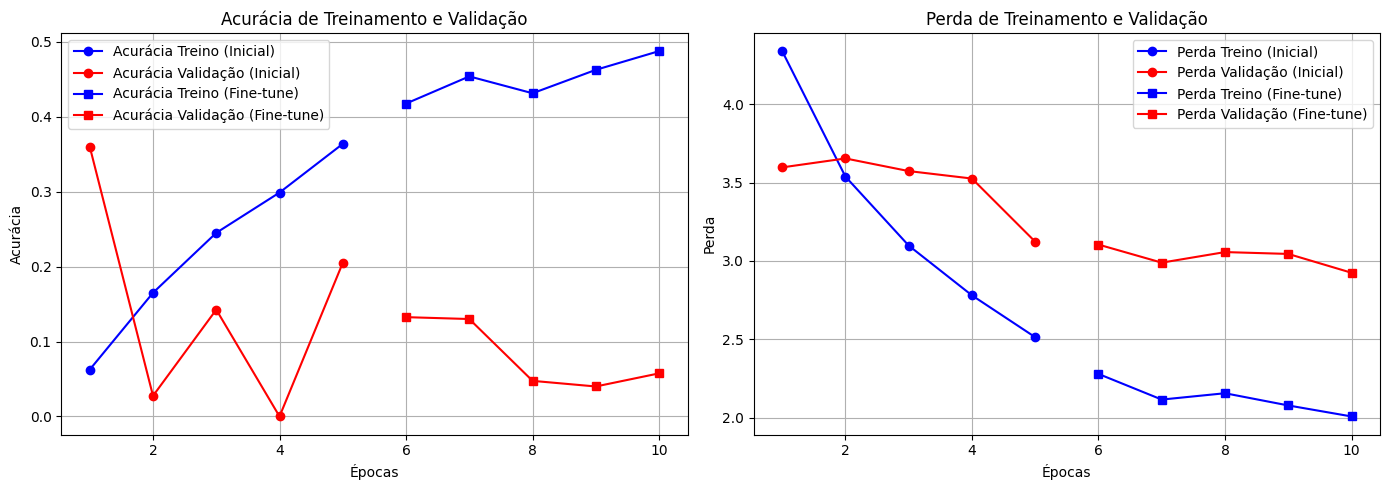

In [10]:
# @title **Etapa 7: Avaliar o modelo no conjunto de teste e exibir a acurácia**

# Para uma avaliação completa, use:
# test_steps_full = test_generator.samples // BATCH_SIZE_SCRIPT
test_steps = 50

print(f"\nAvaliando o modelo no conjunto de teste com test_steps={test_steps}...")
test_loss, test_accuracy = model.evaluate(test_generator, steps=test_steps)
print(f"Acurácia no Teste: {test_accuracy:.4f}")
print(f"Perda no Teste: {test_loss:.4f}")

# Plotar curvas de acurácia e perda
# Função de plotagem combinando history e history_fine
def plot_training_history(initial_history, fine_tune_history):
    acc = initial_history.history['accuracy'] + fine_tune_history.history['accuracy']
    val_acc = initial_history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']
    loss = initial_history.history['loss'] + fine_tune_history.history['loss']
    val_loss = initial_history.history['val_loss'] + fine_tune_history.history['val_loss']

    epochs_initial = range(1, len(initial_history.history['accuracy']) + 1)
    epochs_fine_tune = range(len(initial_history.history['accuracy']) + 1, len(acc) + 1)
    total_epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_initial, initial_history.history['accuracy'], 'bo-', label='Acurácia Treino (Inicial)')
    plt.plot(epochs_initial, initial_history.history['val_accuracy'], 'ro-', label='Acurácia Validação (Inicial)')
    plt.plot(epochs_fine_tune, fine_tune_history.history['accuracy'], 'bs-', label='Acurácia Treino (Fine-tune)')
    plt.plot(epochs_fine_tune, fine_tune_history.history['val_accuracy'], 'rs-', label='Acurácia Validação (Fine-tune)')
    plt.title('Acurácia de Treinamento e Validação')
    plt.xlabel('Épocas')
    plt.ylabel('Acurácia')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_initial, initial_history.history['loss'], 'bo-', label='Perda Treino (Inicial)')
    plt.plot(epochs_initial, initial_history.history['val_loss'], 'ro-', label='Perda Validação (Inicial)')
    plt.plot(epochs_fine_tune, fine_tune_history.history['loss'], 'bs-', label='Perda Treino (Fine-tune)')
    plt.plot(epochs_fine_tune, fine_tune_history.history['val_loss'], 'rs-', label='Perda Validação (Fine-tune)')
    plt.title('Perda de Treinamento e Validação')
    plt.xlabel('Épocas')
    plt.ylabel('Perda')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history, history_fine)


Mapeamento Índice-Classe: {'Apple 10': 0, 'Apple 11': 1, 'Apple 12': 2, 'Apple 13': 3, 'Apple 14': 4, 'Apple 17': 5, 'Apple 18': 6, 'Apple 19': 7, 'Apple 5': 8, 'Apple 7': 9, 'Apple 8': 10, 'Apple 9': 11, 'Apple Core 1': 12, 'Apple Red Yellow 2': 13, 'Apple worm 1': 14, 'Avocado Black 1': 15, 'Avocado Green 1': 16, 'Banana 3': 17, 'Beans 1': 18, 'Blackberrie 1': 19, 'Blackberrie 2': 20, 'Blackberrie half rippen 1': 21, 'Blackberrie not rippen 1': 22, 'Cabbage red 1': 23, 'Cactus fruit green 1': 24, 'Cactus fruit red 1': 25, 'Caju seed 1': 26, 'Cherimoya 1': 27, 'Cherry 3': 28, 'Cherry 4': 29, 'Cherry 5': 30, 'Cherry Rainier 2': 31, 'Cherry Rainier 3': 32, 'Cherry Sour 1': 33, 'Cherry Wax Red 2': 34, 'Cherry Wax Red 3': 35, 'Cherry Wax not ripen 1': 36, 'Cherry Wax not ripen 2': 37, 'Cucumber 10': 38, 'Cucumber 11': 39, 'Cucumber 4': 40, 'Cucumber 5': 41, 'Cucumber 7': 42, 'Cucumber 9': 43, 'Gooseberry 1': 44, 'Pistachio 1': 45, 'Quince 2': 46, 'Quince 3': 47, 'Quince 4': 48, 'Tomato 1

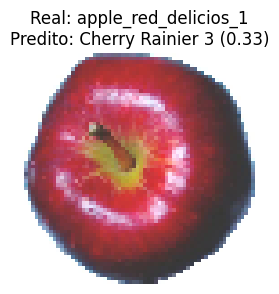

Testando com: /kaggle/input/fruits/fruits-360_original-size/fruits-360-original-size/Test/Cherry 3/r1_95.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


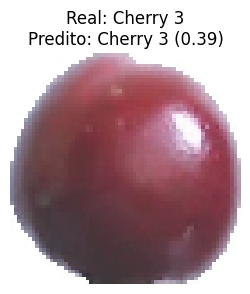

Testando com: /kaggle/input/fruits/fruits-360_original-size/fruits-360-original-size/Test/Avocado Green 1/r1_95.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


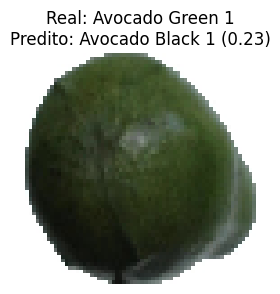

In [11]:
# @title **Etapa 8: Testar predições do modelo em imagens de amostra e visualizar resultados**

# No caso de se utilizar caminhos absolutos para sample_images descomente
# sample_images_base = test_dir # ou dataset_root_path se preferir

# Recuperar o mapeamento de índice de classe do gerador de treinamento
class_index_mapping = train_generator.class_indices
print("\nMapeamento Índice-Classe:", class_index_mapping)
num_classes = len(class_index_mapping)

# Função para obter o nome da classe a partir do índice predito
def get_class_name_from_index(predicted_index, class_idx_mapping):
    for class_name_map, index_map in class_idx_mapping.items():
        if index_map == predicted_index:
            return class_name_map
    return "Desconhecido"

# Definir a função para visualização
# Adicionar 'model_to_predict' e 'target_img_size' como parâmetros
def visualize_prediction_with_actual(img_path, class_idx_mapping, model_to_predict, target_img_size):
    # Extrair o rótulo verdadeiro dinamicamente da estrutura de diretórios
    # Assume que o nome da pasta pai da imagem é o nome da classe
    try:
        true_class_name = os.path.basename(os.path.dirname(img_path))
    except Exception:
        true_class_name = "N/A"

    # Carregar e pré-processar a imagem
    try:
        img = load_img(img_path, target_size=target_img_size)
        img_array_vis = img_to_array(img) # Para visualização
        img_array_pred = img_array_vis / 255.0 # Para predição
        img_array_pred = np.expand_dims(img_array_pred, axis=0)
    except Exception as e:
        print(f"Erro ao carregar imagem {img_path}: {e}")
        return

    # Prever a classe
    prediction_probs = model_to_predict.predict(img_array_pred)
    predicted_index = np.argmax(prediction_probs, axis=-1)[0]
    predicted_class_name = get_class_name_from_index(predicted_index, class_idx_mapping)
    prediction_confidence = np.max(prediction_probs)


    # Visualizar a imagem com as predições
    plt.figure(figsize=(3, 3), dpi=100) # Ajustado para melhor visualização individual
    plt.imshow(img_array_vis.astype(np.uint8)) # Mostrar imagem original antes da normalização
    plt.title(f"Real: {true_class_name}\nPredito: {predicted_class_name} ({prediction_confidence:.2f})")
    plt.axis('off')
    plt.show()

# Definir uma lista de caminhos de imagens de amostra.
# Os caminhos devem ser relativos à pasta raiz do dataset (`dataset_root_path`) ou absolutos.
# A estrutura é dataset_root_path/Test/NomeDaClasse/imagem.jpg

# Utilizar algumas imagens aleatórias do conjunto de teste para visualização
print("\nVisualizando predições em imagens de amostra do conjunto de teste:")
num_sample_images_to_show = 3
count_shown = 0

# Itera sobre as classes no diretório de teste
for class_folder_name in os.listdir(test_dir):
    if count_shown >= num_sample_images_to_show:
        break
    class_folder_path = os.path.join(test_dir, class_folder_name)
    if os.path.isdir(class_folder_path):
        # Pega a primeira imagem (ou uma imagem aleatória) de cada classe
        image_files_in_class = [f for f in os.listdir(class_folder_path) if os.path.isfile(os.path.join(class_folder_path, f))]
        if image_files_in_class:
            sample_image_name = image_files_in_class[0] # Pega a primeira imagem
            sample_image_path = os.path.join(class_folder_path, sample_image_name)
            print(f"Testando com: {sample_image_path}")
            # Passar 'model' e 'TARGET_IMG_SIZE' para a função
            visualize_prediction_with_actual(sample_image_path, class_index_mapping, model, TARGET_IMG_SIZE)
            count_shown += 1


Visualizando predições nas imagens de amostra originais (verifique os nomes das classes):
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


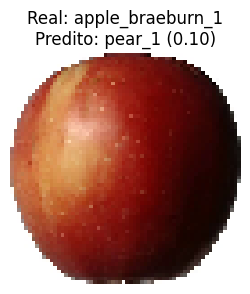

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


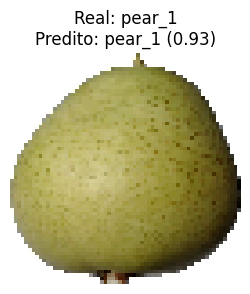

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


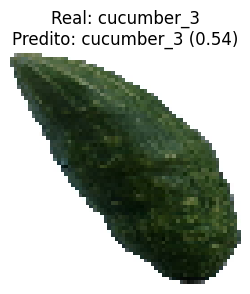

In [12]:
# Para usar as imagens específicas ajuste os caminhos para serem relativos
# a `dataset_root_path` ou `test_dir`
original_sample_images = [
     os.path.join(test_dir, 'apple_braeburn_1/r0_11.jpg'), # Verifique o nome exato da classe 'apple_braeburn_1'
     os.path.join(test_dir, 'pear_1/r0_103.jpg'),          # Verifique o nome exato da classe 'pear_1'
     os.path.join(test_dir, 'cucumber_3/r0_103.jpg'),     # Verifique o nome exato da classe 'cucumber_3'
     ]
print("\nVisualizando predições nas imagens de amostra originais (verifique os nomes das classes):")
for img_path in original_sample_images:
     if os.path.exists(img_path):
         # Passar 'model' e 'TARGET_IMG_SIZE' para a função
         visualize_prediction_with_actual(img_path, class_index_mapping, model, TARGET_IMG_SIZE)
     else:
         print(f"AVISO: Imagem de amostra original não encontrada em: {img_path}")

# **Referências**

* RIBANI, Ricardo; MARENGONI, Mauricio. **A survey of transfer learning for convolutional neural networks**. In: 2019 32nd SIBGRAPI conference on graphics, patterns and images tutorials (SIBGRAPI-T). IEEE, 2019. p. 47-57. Disponível em: